Fetch Stock prices OHLCV Data using yfinance library.

In [2]:
import yfinance as yf
import pandas as pd
from datetime import datetime

# Fetch NVDA daily data
ticker = "NVDA"
start_date = "2016-01-01"
end_date = datetime.now().strftime("%Y-%m-%d")  # up to today (March 18, 2026)

data = yf.download(ticker, start=start_date, end=end_date)
data.to_csv("nvda_prices.csv")

print(data.tail())          # quick check
print(f"Data shape: {data.shape}")

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open     Volume
Ticker            NVDA        NVDA        NVDA        NVDA       NVDA
Date                                                                 
2026-03-11  186.029999  187.619995  184.449997  185.910004  145280400
2026-03-12  183.139999  184.940002  181.750000  184.050003  155762700
2026-03-13  180.250000  186.089996  179.940002  184.919998  160988400
2026-03-16  183.220001  188.880005  181.410004  182.970001  217307400
2026-03-17  181.929993  185.399994  181.680405  185.050003  178520213
Data shape: (2565, 5)


Exploratory Data Analysis to add basic plots to understand NVDA's behavior

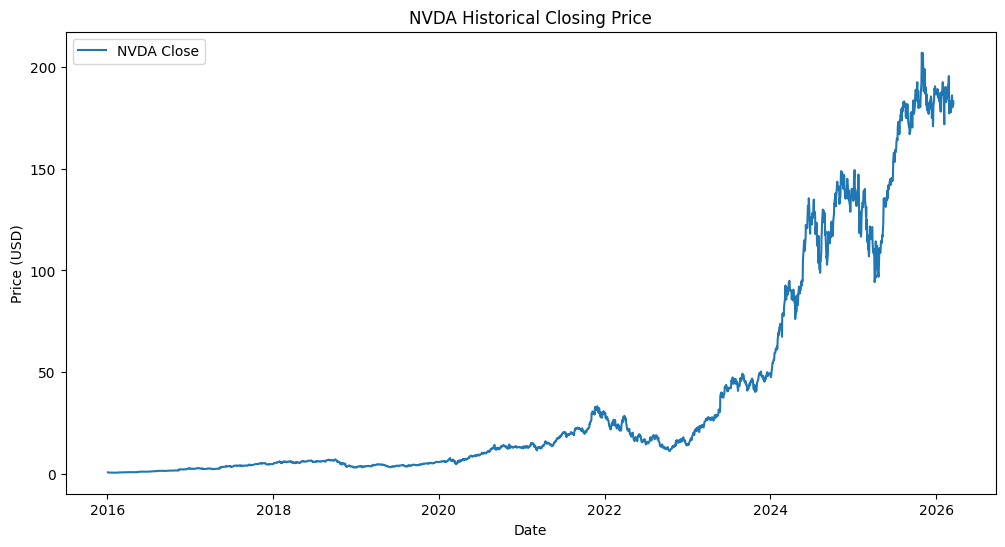

Price         Close         High          Low         Open        Volume
Ticker         NVDA         NVDA         NVDA         NVDA          NVDA
count   2565.000000  2565.000000  2565.000000  2565.000000  2.565000e+03
mean      39.012228    39.669289    38.303192    39.024412  4.533200e+08
std       54.803822    55.666850    53.908372    54.863822  2.578888e+08
min        0.615148     0.623441     0.603684     0.604415  6.552850e+07
25%        4.525436     4.582136     4.455553     4.509233  2.855440e+08
50%       13.303119    13.486099    13.049593    13.308410  4.047390e+08
75%       43.905682    44.722727    43.276734    43.989240  5.528424e+08
max      207.017273   212.166717   205.537422   208.057150  3.692928e+09


In [3]:
import matplotlib.pyplot as plt

# Plot closing price
plt.figure(figsize=(12, 6))
plt.plot(data['Close'], label='NVDA Close')
plt.title('NVDA Historical Closing Price')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

# Basic stats
print(data.describe())

Plotting of Candlestick Chart for Vision Transformation

In [29]:
import pandas as pd
import mplfinance as mpf

# Select required columns safely
required_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
plot_df = data.loc[:, required_cols].copy()

# Drop missing values and limit to last 60 rows
plot_df = plot_df.dropna().tail(60)

# Ensure index is DatetimeIndex
if not isinstance(plot_df.index, pd.DatetimeIndex):
    plot_df.index = pd.to_datetime(plot_df.index, errors='coerce')

# Drop any rows where datetime conversion failed
plot_df = plot_df[~plot_df.index.isna()]

# Sort index (important for plotting)
plot_df = plot_df.sort_index()

# Plot and save
mpf.plot(
    plot_df,
    type='candle',
    style='yahoo',
    volume=True, 
    title='NVDA 60-Day Candlestick Chart',
    ylabel='Price',
    ylabel_lower='Volume',
    datetime_format='%Y-%m-%d',
    savefig=dict(fname='sample_candle_fixed_index.png', dpi=300, bbox_inches='tight')
)